In [3]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [4]:
# =========================================================
# STEP 1: Load and Prepare Data
# =========================================================
print("Loading finalized dataset...")
df = pd.read_csv('final_model_ready_pune_data_ver2.csv')

# Convert date back to datetime and sort chronologically
df['arrival_date'] = pd.to_datetime(df['arrival_date'])
df = df.sort_values(by='arrival_date').reset_index(drop=True)

# Prepare Categoricals for LightGBM
categorical_cols = ['mandi_name', 'district', 'state', 'variety']
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

Loading finalized dataset...


In [5]:
# =========================================================
# STEP 2: Global Chronological Split
# =========================================================
# We use the last 1 year (March 2025 to Feb 2026) as the completely unseen Test Set
split_date = '2025-03-01'
print(f"Splitting data chronologically at {split_date}...")

train_df = df[df['arrival_date'] < split_date].copy()
test_df = df[df['arrival_date'] >= split_date].copy()

# Define columns to drop (identifiers and target)
# We drop 'commodity' because it's completely empty/redundant now
drop_cols = ['arrival_date', 'target_price', 'commodity']

X_train = train_df.drop(columns=drop_cols, errors='ignore')
y_train = train_df['target_price']

X_test = test_df.drop(columns=drop_cols, errors='ignore')
y_test = test_df['target_price']

print(f"Training rows: {len(X_train)} | Testing rows: {len(X_test)}")

Splitting data chronologically at 2025-03-01...
Training rows: 19651 | Testing rows: 5083


In [6]:
# =========================================================
# STEP 3: Create LightGBM Datasets
# =========================================================
lgb_train = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_cols, free_raw_data=False)
lgb_eval = lgb.Dataset(X_test, label=y_test, categorical_feature=categorical_cols, reference=lgb_train, free_raw_data=False)

In [7]:
# =========================================================
# STEP 4: Define Hyperparameters (Optimized)
# =========================================================
params = {
    'objective': 'regression',
    'metric': 'rmse',               # Root Mean Squared Error as the core loss function
    'boosting_type': 'gbdt',
    'learning_rate': 0.03,          # Slightly lower for better generalization
    'num_leaves': 45,               # Increased slightly to capture complex weather/price interactions
    'max_depth': 9,
    'feature_fraction': 0.8,        # Prevents overfitting to a single dominant feature
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'random_state': 42
}

In [8]:
# =========================================================
# STEP 5: Train the Model
# =========================================================
print("\nTraining LightGBM Regressor...")

callbacks = [
    lgb.early_stopping(stopping_rounds=50, first_metric_only=False),
    lgb.log_evaluation(period=100)
]

model = lgb.train(
    params,
    lgb_train,
    num_boost_round=2000,           # High tree count, but early stopping will halt it at the optimal point
    valid_sets=[lgb_train, lgb_eval],
    valid_names=['train', 'eval'],
    callbacks=callbacks
)


Training LightGBM Regressor...
Training until validation scores don't improve for 50 rounds
[100]	train's rmse: 155.753	eval's rmse: 140.5
[200]	train's rmse: 140.162	eval's rmse: 136.156
Early stopping, best iteration is:
[163]	train's rmse: 143.6	eval's rmse: 135.044


In [9]:
# =========================================================
# STEP 6: Formal Error & Accuracy Analysis
# =========================================================
print("\nPredicting on unseen test data...")
y_pred = model.predict(X_test, num_iteration=model.best_iteration)

# Calculate Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100
r2 = r2_score(y_test, y_pred)

print(f"\n" + "="*40)
print(f"   FINAL MODEL PERFORMANCE REPORT")
print(f"="*40)
print(f"1. RMSE (Root Mean Squared Error): ₹{rmse:.2f} / Quintal")
print(f"   (Average magnitude of error, penalizes large mistakes heavily)")
print(f"2. MAE  (Mean Absolute Error):     ₹{mae:.2f} / Quintal")
print(f"   (On average, the model's prediction is off by this amount)")
print(f"3. MAPE (Mean Abs Percentage Err): {mape:.2f}%")
print(f"   (The percentage by which the prediction deviates from actual)")
print(f"4. R-Squared (R² Score):           {r2:.4f}")
print(f"   (Explains {r2*100:.2f}% of the variance in onion prices)")
print(f"="*40)

# Save metrics to a text file for documentation
with open("model_performance_report.txt", "w") as f:
    f.write(f"RMSE: {rmse}\nMAE: {mae}\nMAPE: {mape}\nR2: {r2}\n")


Predicting on unseen test data...

   FINAL MODEL PERFORMANCE REPORT
1. RMSE (Root Mean Squared Error): ₹135.04 / Quintal
   (Average magnitude of error, penalizes large mistakes heavily)
2. MAE  (Mean Absolute Error):     ₹78.72 / Quintal
   (On average, the model's prediction is off by this amount)
3. MAPE (Mean Abs Percentage Err): 6.29%
   (The percentage by which the prediction deviates from actual)
4. R-Squared (R² Score):           0.9699
   (Explains 96.99% of the variance in onion prices)



Saved 'feature_importance.png'
Saved 'actual_vs_predicted_pune.png'
Model saved successfully as 'lightgbm_onion_1day_horizon_final.txt'


<Figure size 1000x600 with 0 Axes>

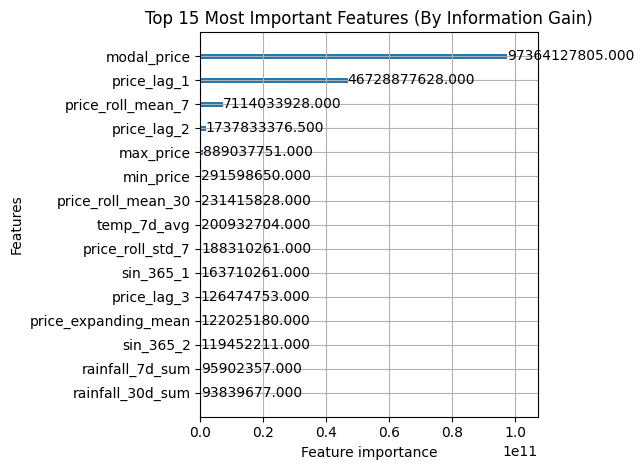

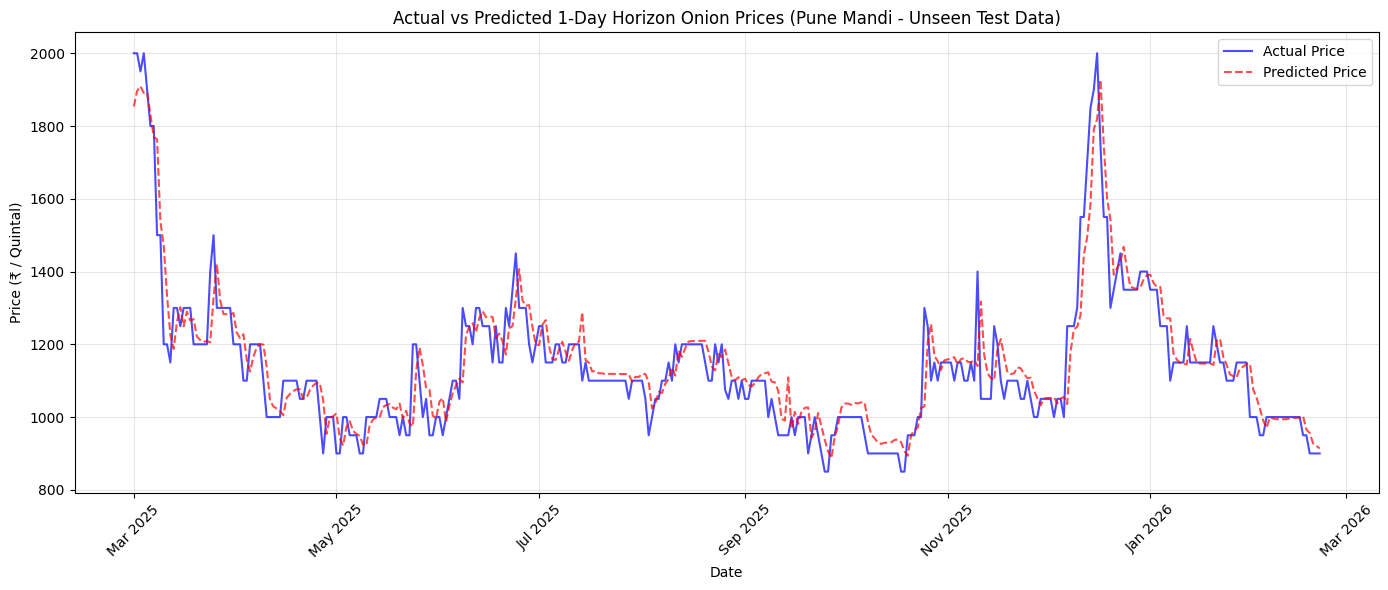

In [10]:
# =========================================================
# STEP 7: Documentation & Visual Analysis
# =========================================================

# Plot 1: Feature Importance (Which variables drive the price?)
plt.figure(figsize=(10, 6))
lgb.plot_importance(model, max_num_features=15, importance_type='gain', 
                    title='Top 15 Most Important Features (By Information Gain)')
plt.tight_layout()
plt.savefig('feature_importance.png')
print("\nSaved 'feature_importance.png'")

# Plot 2: Actual vs Predicted Time Series for a specific Mandi
# This is crucial for visual documentation. We will plot the Pune mandi specifically.
pune_test = test_df[(test_df['mandi_name'] == 'Pune') & (test_df['variety'] == 'Local')].copy()

if not pune_test.empty:
    # Get predictions specifically for this subset
    X_pune = pune_test.drop(columns=drop_cols, errors='ignore')
    pune_test['predicted_price'] = model.predict(X_pune, num_iteration=model.best_iteration)
    
    plt.figure(figsize=(14, 6))
    plt.plot(pune_test['arrival_date'], pune_test['target_price'], label='Actual Price', color='blue', alpha=0.7)
    plt.plot(pune_test['arrival_date'], pune_test['predicted_price'], label='Predicted Price', color='red', alpha=0.7, linestyle='--')
    
    plt.title('Actual vs Predicted 1-Day Horizon Onion Prices (Pune Mandi - Unseen Test Data)')
    plt.xlabel('Date')
    plt.ylabel('Price (₹ / Quintal)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Format x-axis for better date readability
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.savefig('actual_vs_predicted_pune.png')
    print("Saved 'actual_vs_predicted_pune.png'")

# Save the finalized model
model.save_model('lightgbm_onion_1day_horizon_final.txt')
print("Model saved successfully as 'lightgbm_onion_1day_horizon_final.txt'")

In [1]:
import joblib
model_path = 'lightgbm_onion_1day_horizon_final.pkl'
joblib.dump(model, model_path)

print(f"Model successfully saved in pickle format at: {model_path}")

NameError: name 'model' is not defined